## Analisi traffico

In [43]:
%reload_ext autoreload
%autoreload 2

In [44]:
import pandas as pd

### Import data    

In [45]:
data = pd.read_csv('weekly_traffic_by_category.csv')

data.head()

,week_name,pagePath,sessions,engagedSessions,screenPageViews,category
0,25011,/419840/latest-news/alice-in-borderland-3-e-vi...,1253,736,1256,News
1,25011,/389791/latest-news/anticipazioni/suburraetern...,259,150,259,Anticipazioni
2,25011,/420566/taxidrivers-magazine/acab-la-serie-dal...,162,101,171,Speciali e Magazine
3,25011,/279976/review/approfondimenti/venti-film-sull...,142,70,150,Recensioni
4,25011,/419995/magazine-2/golden-globes-2025-i-vincit...,141,75,155,Speciali e Magazine


### Enrich data

In [46]:
# Enrich data
data['engagement_rate'] = data['engagedSessions'] / data['sessions']

In [47]:
data.describe()

,week_name,sessions,engagedSessions,screenPageViews,engagement_rate
count,267832.000000,267832.000000,267832.000000,267832.000000,267832.000000
mean,25327.076746,4.179904,2.553967,4.327224,0.626963
std,419.758592,18.403993,11.058057,18.920903,0.418828
min,25011.000000,1.000000,0.000000,0.000000,0.000000
25%,25062.000000,1.000000,0.000000,1.000000,0.000000
50%,25101.000000,1.000000,1.000000,1.000000,0.800000
75%,26011.000000,3.000000,2.000000,3.000000,1.000000
max,26044.000000,1594.000000,996.000000,1620.000000,1.000000


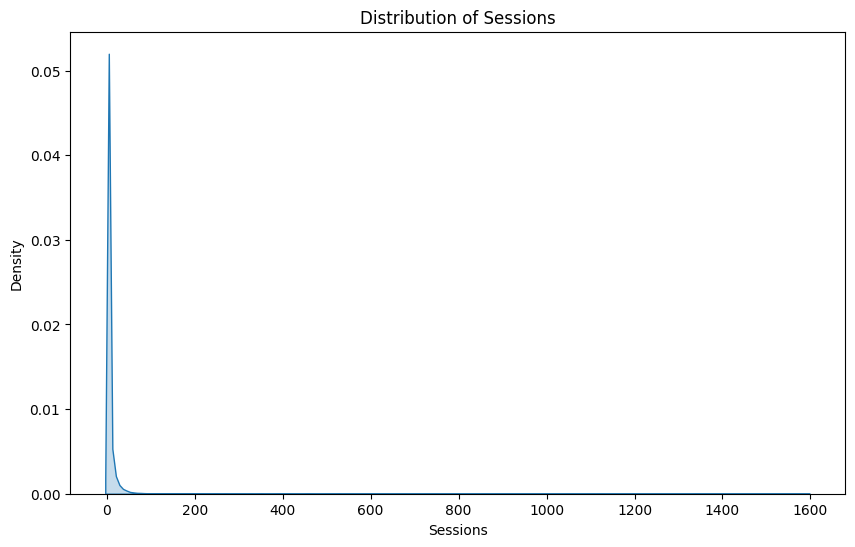

In [48]:
# Kde plot of sessions
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.kdeplot(data=data, x='sessions', fill=True)
plt.title('Distribution of Sessions')
plt.xlabel('Sessions')
plt.ylabel('Density')
plt.show()

In [49]:
threshold = 0.9
percentile_at_threshold = data['sessions'].quantile(threshold)
print(f'percentile of sessions at threshold {threshold}: {percentile_at_threshold}')

percentile of sessions at threshold 0.9: 7.0


Il 57% degli articoli riceve meno di 1 visualizzazione nella settimana (concatenando le settimane)

Per ogni settimana, è stato considerato solo il set di articoli che ha generato un numero minimo di sessioni, con soglia inferiore corrispondente al 90-esimo percentile della distribuzione delle sessioni. In questo modo ci assicuriamo che gli articoli inclusi nel set di analisi di ogni settimana includa in maggioranza articoli pubblicati in quella stessa settimana [TODO]. Resta comunque un'ipotesi da confermare.    

### Process data by week

In [50]:
def _filter_top_sessions(data, threshold=0.9):
    percentile_at_threshold = data['sessions'].quantile(threshold)
    print(f'percentile of sessions at threshold {threshold}: {percentile_at_threshold}')
    filtered_data = data[data['sessions'] > percentile_at_threshold]
    return filtered_data
    
def _process_week(data, week):
    threshold = 0.9
    week_data = data[data['week_name'] == week]
    filtered_data = _filter_top_sessions(week_data, threshold)
    return filtered_data

def process_all_weeks(data):
    weeks = data['week_name'].unique()
    all_processed_data = pd.DataFrame()
    for week in weeks:
        filtered_data = _process_week(data, week)
        all_processed_data = pd.concat([all_processed_data, filtered_data], ignore_index=True)
    return all_processed_data

processed_data = process_all_weeks(data)


percentile of sessions at threshold 0.9: 7.0
percentile of sessions at threshold 0.9: 7.0
percentile of sessions at threshold 0.9: 8.0
percentile of sessions at threshold 0.9: 7.0
percentile of sessions at threshold 0.9: 7.0
percentile of sessions at threshold 0.9: 7.0
percentile of sessions at threshold 0.9: 7.0
percentile of sessions at threshold 0.9: 8.0
percentile of sessions at threshold 0.9: 6.0
percentile of sessions at threshold 0.9: 8.0
percentile of sessions at threshold 0.9: 7.0
percentile of sessions at threshold 0.9: 7.0
percentile of sessions at threshold 0.9: 8.0
percentile of sessions at threshold 0.9: 7.0
percentile of sessions at threshold 0.9: 6.0
percentile of sessions at threshold 0.9: 7.0
percentile of sessions at threshold 0.9: 7.0
percentile of sessions at threshold 0.9: 6.0
percentile of sessions at threshold 0.9: 7.0
percentile of sessions at threshold 0.9: 7.0
percentile of sessions at threshold 0.9: 7.0
percentile of sessions at threshold 0.9: 7.0
percentile

In [51]:
# Compute count of rows in processed_data for each week
n_articles_by_month = processed_data.groupby('week_name').size()

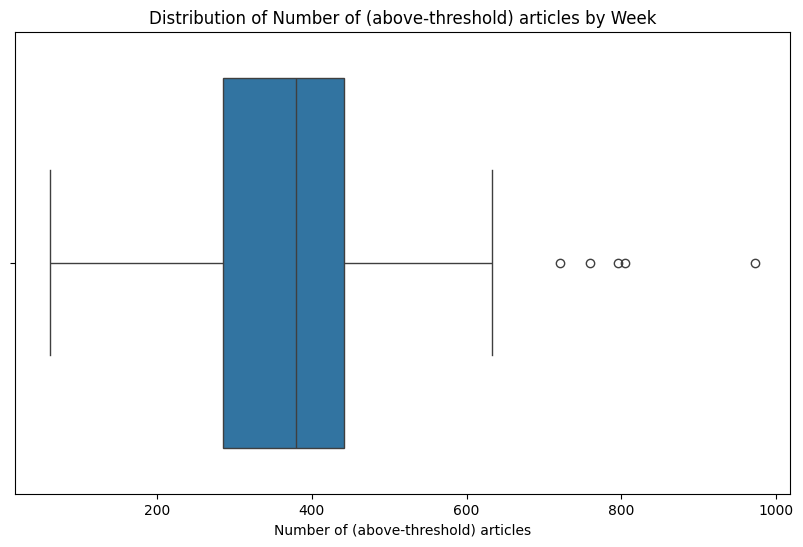

In [52]:
# Boxplot of n_articles_by_month
plt.figure(figsize=(10, 6))
sns.boxplot(x=n_articles_by_month)
plt.title('Distribution of Number of (above-threshold) articles by Week')
plt.xlabel('Number of (above-threshold) articles')
plt.show()

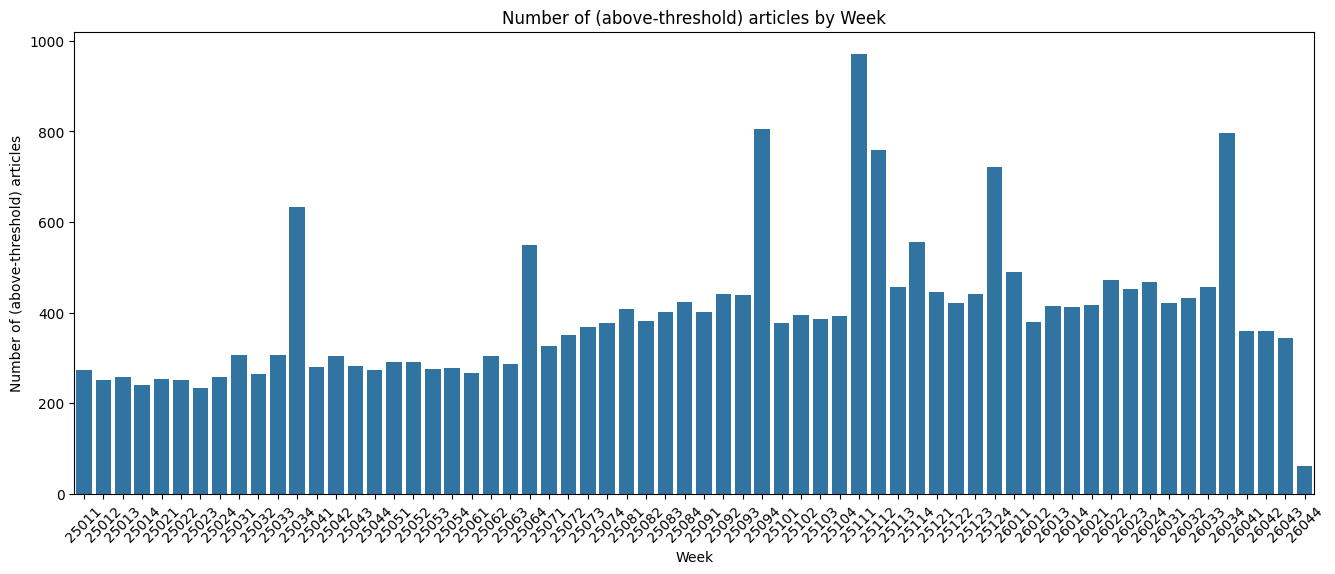

In [53]:
# Lollipop chart of n_articles_by_month
plt.figure(figsize=(16, 6))
sns.barplot(x=n_articles_by_month.index, y=n_articles_by_month.values)
plt.title('Number of (above-threshold) articles by Week')
plt.xlabel('Week')
plt.ylabel('Number of (above-threshold) articles')
plt.xticks(rotation=45)
plt.show()

Il numero di articoli sopra il 90-esimo percentile aumenta nel tempo, segno di un trend al rialzo rispetto allo scorso anno.

Nel tempo è aumentato il numero di articoli che ricevono un numero di visualizzazioni rilevante.  
Le disparità restano comunque rilevanti [TODO] Articoli nuovi che ricevono poche visualizzazioni].

Siamo ancora al di sopra del valore soglia della prima settimana di gennaio 25 [quale margine %?]

In [54]:
# Numero di articoli che hanno generato un numero di visualizzazioni significativo per cateogoria,
# raggruppato per settimana. 

count_of_categories_by_week = processed_data.groupby(['week_name', 'category']).size().unstack(fill_value=0)


## Analisi d'impatto delle categorie

Vuoi stimare l'effetto causale (o almeno l'associazione predittiva) tra la distribuzione degli articoli ad alto traffico per categoria e la crescita complessiva del sito. Il tuo proxy di "qualità/impatto editoriale" è già buono: contare gli articoli sopra il 90° percentile delle visualizzazioni è una misura più significativa del semplice volume.

### Approccio consigliato: analisi in due livelli
*Livello 1 — Analisi esplorativa e correlazione laggata*
Prima di modellare, capisci la struttura dei dati.  

- *Cross-correlation con lag temporali:* 
per ogni categoria, calcola la correlazione tra il numero di articoli top-performing nella settimana t e la crescita di traffico totale del sito nelle settimane t, t+1, t+2, t+3. Questo ti dice se una categoria "anticipa" la crescita o se è contemporanea ad essa. Le categorie con correlazione alta a lag t+1 o t+2 sono candidati causali più credibili.

- *Decomposizione della varianza*: 
quanta parte della variabilità settimanale del traffico è spiegata da ciascuna categoria? Una regressione OLS multivariata con le categorie come predittori ti dà già una prima risposta, anche se naive.


*Livello 2 — Modello principale: regressione con effetti distribuiti nel tempo (ARDL o VAR)*

Dato che hai serie temporali (63 settimane), il metodo più robusto è un modello *ARDL (Autoregressive Distributed Lag)* oppure un *VAR (Vector Autoregression)* ridotto. 

Il razionale è che il traffico di questa settimana dipende dal traffico della settimana scorsa (inerzia) più il contributo degli articoli top di ciascuna categoria con un certo ritardo. Questo ti permette di isolare il contributo netto di ogni categoria al netto dell'autocorrelazione del traffico stesso. 

*Con il VAR puoi anche fare Granger causality test* per ogni categoria: testa formalmente se sapere quanti articoli top ha prodotto la categoria X nelle ultime k settimane migliora la previsione del traffico futuro. È il test più difendibile metodologicamente in assenza di un esperimento controllato.

Ci sono però dei *caveaut*. 

Non avere il numero di articoli pubblicati per settimana è un problema reale perché non puoi normalizzare (articoli top / articoli totali). Hai due strade:

- Puoi usare il dato grezzo come proxy assoluto — ma funziona solo se le categorie hanno una produzione editoriale relativamente stabile nel tempo.
- Puoi stimare la produzione con un proxy indiretto — se hai accesso a dati come la data di pubblicazione degli articoli (anche aggregata), puoi ricostruire un conteggio approssimato. 


*Output atteso dell'analisi*
Al termine avrai, per ogni categoria:

- un coefficiente di impatto sul traffico (con e senza lag)
- un p-value del test di Granger per valutare la significatività
- una stima del lag ottimale (dopo quante settimane si manifesta l'effetto)

Questo ti permette di dire, per esempio: 
>*"Gli articoli top della categoria Sport si associano a un aumento di traffico significativo con 2 settimane di anticipo, mentre la categoria Economia ha un effetto contemporaneo ma non predittivo".*

## Analisi: Livello 1

### Cross-correlation con lag temporali


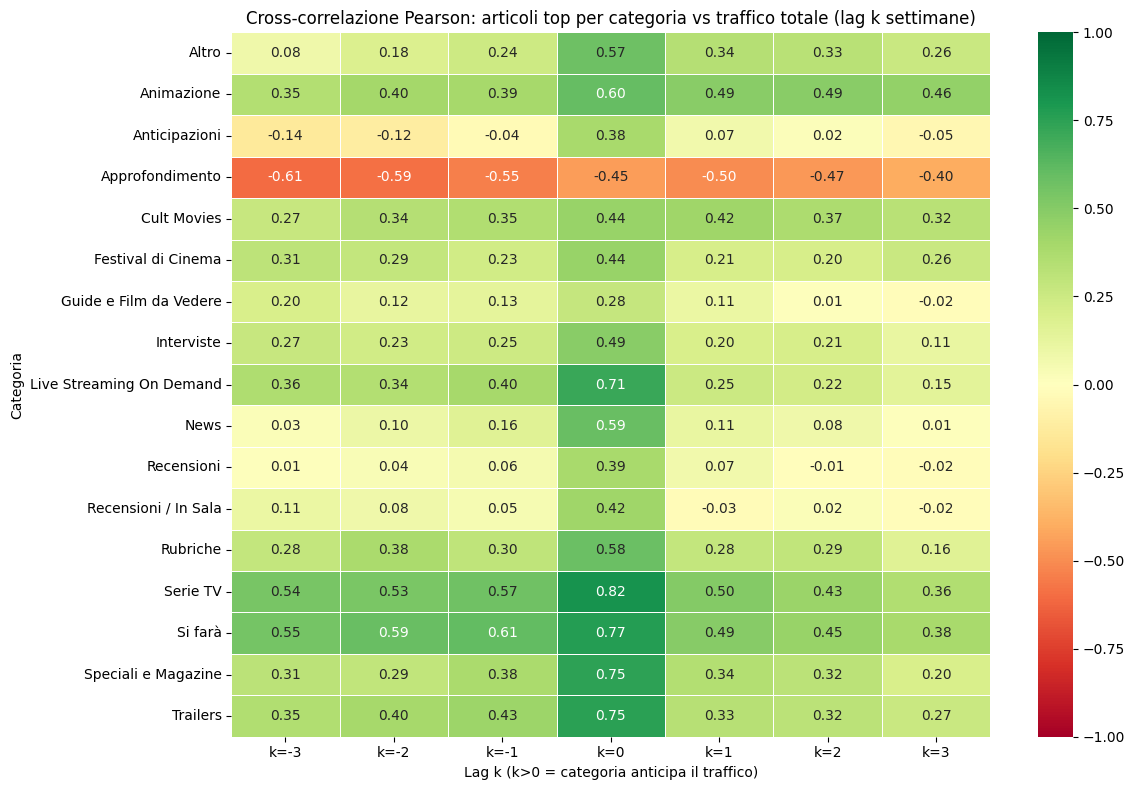

,-3,-2,-1,0,1,2,3
category,,,,,,,
Altro,0.081077,0.182588,0.243935,0.571823,0.343373,0.327526,0.261425
Animazione,0.346579,0.401845,0.393461,0.596125,0.488866,0.489877,0.459820
Anticipazioni,-0.135467,-0.115449,-0.038065,0.383430,0.074540,0.016047,-0.049020
Approfondimento,-0.607026,-0.591471,-0.546519,-0.447080,-0.501108,-0.465492,-0.402496
Cult Movies,0.272877,0.336689,0.353061,0.438793,0.417821,0.367842,0.323346
Festival di Cinema,0.308468,0.285872,0.233733,0.440428,0.207851,0.204864,0.264213
Guide e Film da Vedere,0.202163,0.119314,0.134370,0.280976,0.107415,0.013481,-0.018035
Interviste,0.269854,0.232931,0.249618,0.485601,0.202355,0.206502,0.111600
Live Streaming On Demand,0.359930,0.344053,0.397636,0.712165,0.253256,0.223633,0.146679


In [55]:
# Per ogni categoria, calcola la correlazione di Pearson tra il conteggio settimanale
# degli articoli top di quella categoria e il traffico totale del sito shiftato di k settimane.
# k > 0: la categoria "anticipa" il traffico futuro (candidato causale)
# k < 0: la categoria segue il traffico (effetto reattivo)
# k = 0: correlazione contemporanea

k_list = [-3, -2, -1, 0, 1, 2, 3]

# Traffico totale del sito per settimana (su tutti gli articoli, non solo filtered)
total_traffic = (
    processed_data.groupby("week_name")["screenPageViews"]
    .sum()
    .sort_index()
)

# Conteggio articoli top per categoria per settimana (già calcolato)
cat_counts = count_of_categories_by_week.sort_index()

# Allinea gli indici
cat_counts, total_traffic = cat_counts.align(total_traffic, join="inner", axis=0)

# Calcola la cross-correlation per ogni categoria e ogni lag
corr_matrix = pd.DataFrame(index=cat_counts.columns, columns=k_list, dtype=float)

for cat in cat_counts.columns:
    cat_series = cat_counts[cat]
    for k in k_list:
        # shift(k): traffico shiftato in avanti di k → misura se cat predice traffico a t+k
        corr_matrix.loc[cat, k] = cat_series.corr(total_traffic.shift(-k))

corr_matrix = corr_matrix.astype(float)

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    xticklabels=[f"k={k}" for k in k_list],
)
plt.title("Cross-correlazione Pearson: articoli top per categoria vs traffico totale (lag k settimane)")
plt.xlabel("Lag k (k>0 = categoria anticipa il traffico)")
plt.ylabel("Categoria")
plt.tight_layout()
plt.show()

corr_matrix

Le categorie con più alta correlazione col traffico sono ...

A k negativi la lettura si inverte: la buona performance di "Si farà" 
questa settimana precede un traffico alto nelle settimane successive.

ACTIONABLE: Le recensioni sono un tipo di contenuto da pubblicare 
a ridosso dell'uscita del titolo.

Un effetto simile si osserva per:
- le anticipazioni
- news
- guide e film da vedere

Le categorie che, al contrario, hanno un impatto non solo nel breve 
ma anche nel medio termine (seppure più contenuto), sono:
- Si farà
- Serie TV
- Speciali e Magazine
- Trailers
- Rubriche
- Interviste
- Festival di Cinema

Gli effetti più stabili nel tempo si osservano per due categorie:
- Cult Movies (categoria il cui effetto positivo è il più stabile nel tempo).
- Animazione

La reale presenza di questi effetti positivi resta comunque 
un'ipotesi da verificare.

Guardando le colonne k=-3, k=-2, k=-1, "Si farà" è la categoria 
con valori relativamente alti anche a lag negativo (0.55, 0.59, 0.61). 
Ha senso semanticamente: è una categoria di annunci e anticipazioni 
che genera interesse prima che il contenuto principale arrivi sul sito.

Tecnicamente: a k=-1 stai correlando Si farà[t] con traffico[t+1], 
cioè il traffico della settimana successiva. Il fatto che la 
correlazione sia alta significa che quando "Si farà" performa bene 
questa settimana, il traffico tende a crescere la settimana dopo.

La *leva strategica* si può riassumere così: 
> Quando escono molti articoli top in "Si farà" questa settimana, 
> il traffico tende a crescere nelle settimane successive.

Cosa puoi dire
Puoi dire che "Si farà" è un indicatore anticipatore del traffico: quando il numero di articoli top in questa categoria è alto nella settimana t, il traffico tende a essere più alto nelle settimane successive. Il pattern è coerente e statisticamente visibile sui lag k=-1, k=-2, k=-3.
Cosa non puoi ancora dire
Non puoi dire che è causalmente predittiva, per due motivi:

La correlazione non esclude una terza variabile: potrebbe essere che un evento esterno — l'annuncio di una serie molto attesa, un festival, una stagione televisiva — spinga contemporaneamente sia la produzione editoriale di "Si farà" sia il traffico futuro. In quel caso la categoria non genera il traffico, lo riflette entrambi.
Non hai ancora controllato per le altre categorie: nella regressione OLS potresti scoprire che l'effetto di "Si farà" si riduce o scompare quando tieni costante Serie TV o Animazione.

La formulazione corretta

>"Si farà" è la categoria con il segnale anticipatore più robusto nel dataset: le sue performance a lag negativo suggeriscono un effetto predittivo sul traffico futuro, che andrà confermato con il test di Granger al Livello 2.

## Cos'è la decomposizione della varianza

Il traffico del tuo sito non è costante: alcune settimane è alto, altre basso. Questa variabilità ha delle cause. La domanda è: **quanto di questa oscillazione è spiegato da ciascuna categoria editoriale?**

L'idea di base è semplice. Il traffico totale in una settimana lo puoi immaginare come la somma di contributi:

> *traffico = quota spiegata dalle categorie + quota inspiegata (rumore)*

La regressione OLS stima quanto ogni categoria contribuisce alla parte spiegata, e l'**R²** (coefficiente di determinazione) ti dice la dimensione complessiva di quella parte: un R²=0.80 significa che le tue categorie spiegano l'80% della variabilità del traffico, il restante 20% è dovuto a fattori non osservati nel tuo dataset.

## Cosa aggiunge il coefficiente di ogni categoria

L'OLS multivariata fa una cosa in più rispetto alla semplice correlazione: stima il contributo di ciascuna categoria **tenendo costanti tutte le altre**. Questo è importante perché Serie TV e Si farà, per esempio, potrebbero muoversi insieme — e senza controllare per questa sovrapposizione rischi di sovrastimare il contributo di entrambe.

Il coefficiente che ottieni per ogni categoria risponde a questa domanda: *se questa settimana escono un articolo top in più in questa categoria, e tutto il resto rimane uguale, di quanto tende a cambiare il traffico?*

## Perché è "naive"

Il modello è naive per tre ragioni principali:

1. **Non considera il tempo**: tratta ogni settimana come indipendente dalle altre, ignorando che il traffico di questa settimana dipende anche da quello della settimana scorsa.
2. **Assume linearità**: ipotizza che il rapporto tra ogni categoria e il traffico sia costante, il che nella realtà non è sempre vero.
3. **Non gestisce la stagionalità**: un picco di traffico a dicembre potrebbe essere Natale, non le categorie editoriali.

Nonostante questo, rimane un ottimo punto di partenza per capire **quali categorie contano di più**, prima di passare a modelli più sofisticati al Livello 2.

In [ ]:
# Standardizza le variabili
# scipy.stats.zscore
from scipy.stats import zscore

# standardize count_of_categories_by_week
cat_counts_standardized = cat_counts.apply(zscore)
cat_counts_standardized.head()


category,Altro,Animazione,Anticipazioni,Approfondimento,Cult Movies,Festival di Cinema,Guide e Film da Vedere,Interviste,Live Streaming On Demand,News,Recensioni,Recensioni / In Sala,Rubriche,Serie TV,Si farà,Speciali e Magazine,Trailers
week_name,,,,,,,,,,,,,,,,,
25011,-0.851956,-0.625861,0.208652,1.500610,-0.642891,-1.146863,1.961630,-0.631624,-0.018652,-0.416024,-0.252342,0.064991,-1.343046,-0.743608,-1.227995,-0.279767,-1.226874
25012,-0.699224,-0.625861,-0.371944,1.500610,-0.642891,-0.749343,-0.202927,-0.465952,-0.506987,-0.690919,-1.091299,0.632185,-0.784897,-0.597474,-1.227995,-0.724920,-1.226874
25013,-0.241030,-0.625861,-0.299370,1.500610,-0.642891,-0.437006,1.240111,-0.465952,-0.886804,-0.690919,-0.462082,0.064991,-0.784897,-0.889742,-1.227995,-0.724920,-1.361556
25014,-0.393761,-0.625861,-0.589668,2.552132,-0.642891,-1.090075,1.240111,-0.631624,-0.235690,-0.848002,-0.462082,-0.691268,-0.226748,-0.841031,-1.227995,-0.774382,-1.092191
25021,-0.546493,-0.625861,-0.589668,2.201625,-0.642891,-0.976497,-0.202927,-0.134608,-0.127171,-0.690919,-0.776690,-0.124074,-0.226748,-0.841031,-1.227995,-0.527074,-0.957509


In [ ]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Aggiungi la costante PRIMA di calcolare il VIF
cat_counts_with_const = add_constant(cat_counts_standardized)

# Calcola il VIF escludendo la colonna della costante dall'output
vif_data = pd.DataFrame()
vif_data["feature"] = cat_counts_standardized.columns
vif_data["VIF"] = [
    variance_inflation_factor(cat_counts_with_const.values, i + 1)  # i+1 per saltare la costante
    for i in range(cat_counts_standardized.shape[1])
]

vif_data.sort_values("VIF", ascending=False)

,feature,VIF
13,Serie TV,26.918256
14,Si farà,21.045380
15,Speciali e Magazine,15.762004
8,Live Streaming On Demand,10.289791
9,News,6.598214
16,Trailers,5.202234
2,Anticipazioni,5.059232
0,Altro,4.164643
7,Interviste,3.919664
3,Approfondimento,3.863279


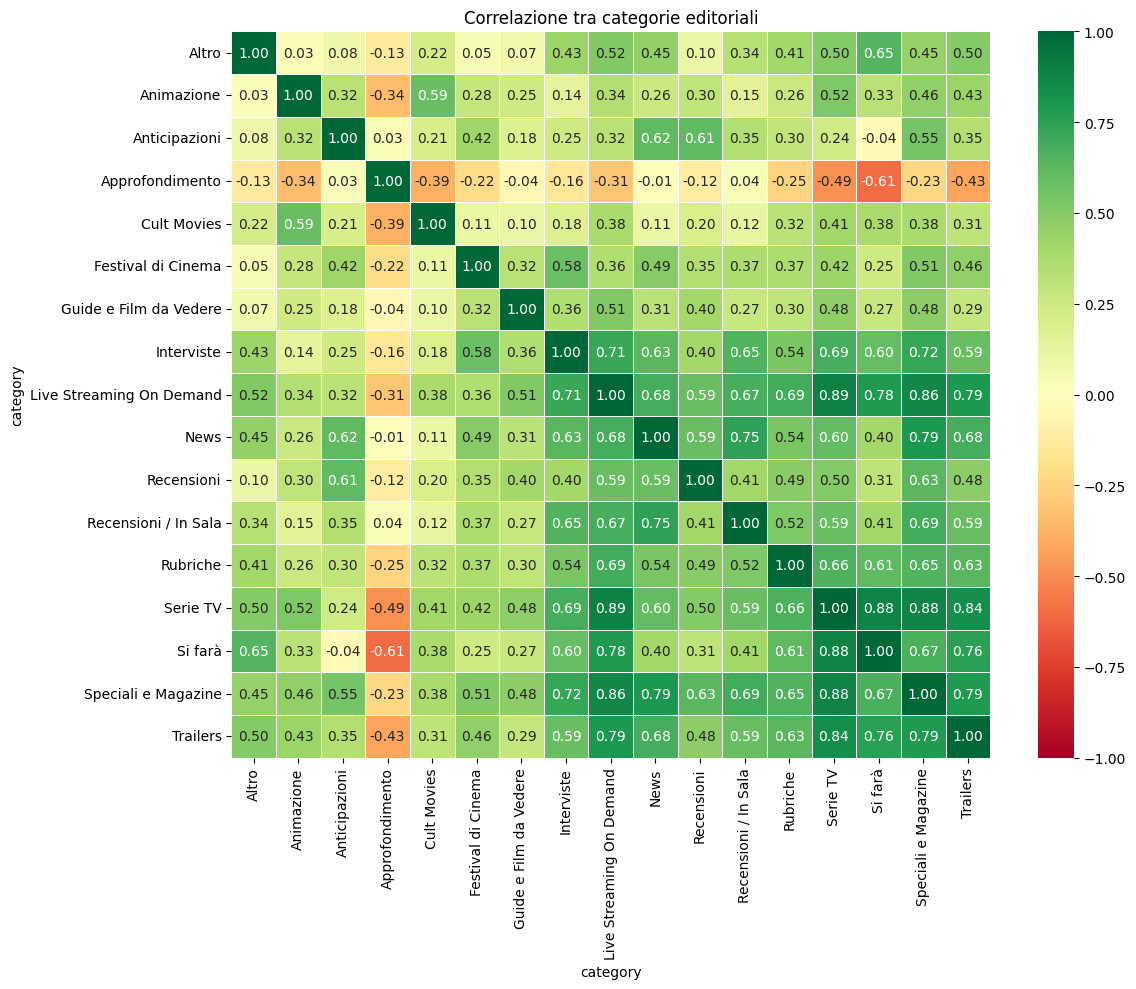

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = cat_counts_standardized.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title("Correlazione tra categorie editoriali")
plt.tight_layout()
plt.show()

In [69]:
from scipy import stats

coppie_sospette = [
    ("Serie TV", "Si farà"),
    ("Serie TV", "Speciali e Magazine"),
    ("Si farà", "Speciali e Magazine"),
    ("Live Streaming On Demand", "News"),
]

for cat1, cat2 in coppie_sospette:
    r, p = stats.pearsonr(
        cat_counts_standardized[cat1],
        cat_counts_standardized[cat2]
    )
    print(f"{cat1} × {cat2}: r={r:.3f}, p={p:.4f}")

Serie TV × Si farà: r=0.882, p=0.0000
Serie TV × Speciali e Magazine: r=0.876, p=0.0000
Si farà × Speciali e Magazine: r=0.667, p=0.0000
Live Streaming On Demand × News: r=0.684, p=0.0000


Serie TV ha VIF = 26.9 — significa che se regredisci Serie TV su tutte le altre categorie ottieni un R² di circa 0.96. In altre parole, il 96% della variabilità settimanale di Serie TV è già contenuta nelle altre categorie. Il modello OLS non riesce a capire se il traffico sale grazie a Serie TV o grazie a qualcos'altro che si muove insieme ad essa.

In generale, Serie TV, Si farà e Speciali e Magazine si muovono quasi in sincronia — probabilmente perché seguono tutte e tre il calendario televisivo. Quando inizia una stagione TV forte, tutte e tre salgono insieme. L'OLS vede traffico alto in quelle settimane ma non riesce ad attribuirlo a una delle tre in particolare: i coefficienti che ottieni per queste categorie sono numericamente casuali, nel senso che potrebbero cambiare drasticamente se rimuovessi anche solo una di esse dal modello.

L'insight

>"Serie TV, Si farà e Speciali e Magazine sono di fatto un unico motore di traffico: si muovono insieme e dominano la variabilità settimanale del sito. Investire su una senza le altre due è inefficiente — vanno pianificate come un sistema editoriale coordinato, non come categorie separate."

Il VIF altissimo di queste tre categorie (27, 21, 16) non è un problema statistico da risolvere — è una scoperta editoriale: queste categorie condividono lo stesso pubblico, lo stesso calendario (la stagione televisiva) e lo stesso meccanismo di interesse. 

Escluse per VIF critico: []
Incluse nel modello OLS: ['Altro', 'Animazione', 'Anticipazioni', 'Approfondimento', 'Cult Movies', 'Festival di Cinema', 'Guide e Film da Vedere', 'Interviste', 'Live Streaming On Demand', 'News', 'Recensioni', 'Recensioni / In Sala', 'Rubriche', 'Serie TV', 'Si farà', 'Speciali e Magazine', 'Trailers']
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.895
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     22.99
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           5.99e-17
Time:                        14:53:21   Log-Likelihood:                -18.781
No. Observations:                  64   AIC:                             73.56
Df Residuals:                      46   BIC:                             112.4
Df Model:                         

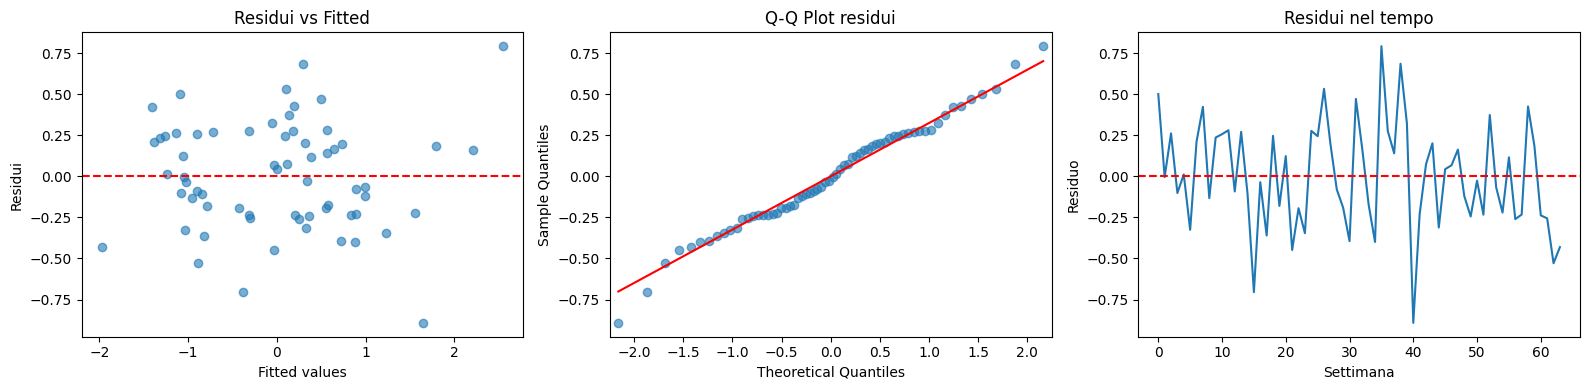


Durbin-Watson: 1.751  (target ≈ 2.0)


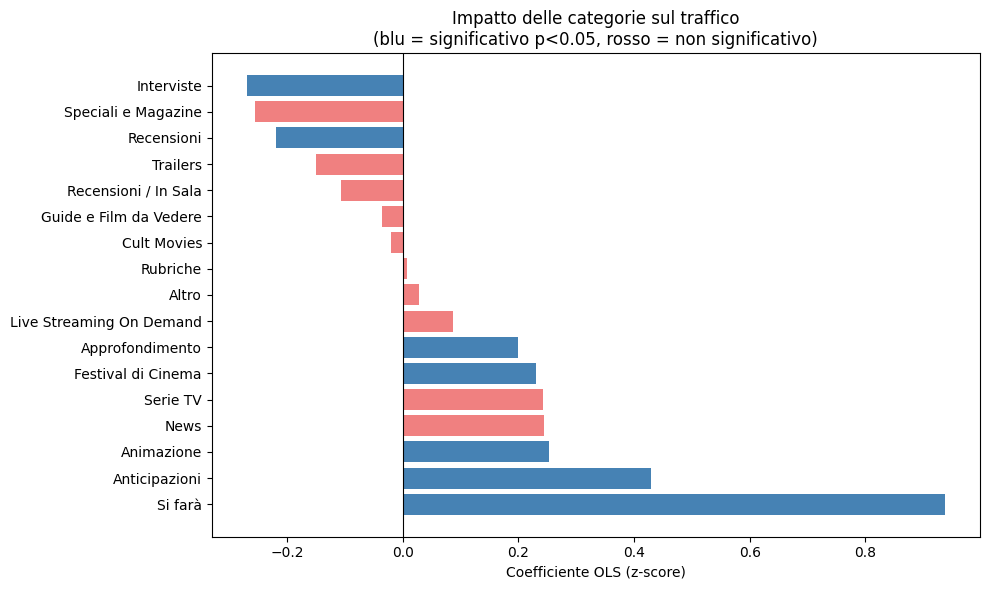

In [70]:
import statsmodels.api as sm



# ── STEP 1: rimuovi le categorie con VIF critico ─────────────────────
# Soglia conservativa: VIF > 10 fuori dal modello OLS
# (trattate separatamente al Livello 2 con VAR)
HIGH_VIF_THRESHOLD = 30
high_vif_cats = vif_data[vif_data["VIF"] > HIGH_VIF_THRESHOLD]["feature"].tolist()
low_vif_cats  = vif_data[vif_data["VIF"] <= HIGH_VIF_THRESHOLD]["feature"].tolist()

print(f"Escluse per VIF critico: {high_vif_cats}")
print(f"Incluse nel modello OLS: {low_vif_cats}")

# ── STEP 2: prepara X e y ────────────────────────────────────────────
# y: traffico standardizzato (deve essere nella stessa scala di X)
y = processed_data.groupby("week_name")["screenPageViews"].sum().sort_index()
y = zscore(y)  # standardizza y per essere nella stessa scala di X

# X: solo categorie con VIF accettabile + costante
X = cat_counts_standardized[low_vif_cats]
X = add_constant(X)

# ── STEP 3: fitta il modello OLS ─────────────────────────────────────
model  = sm.OLS(y, X).fit()
print(model.summary())

# ── STEP 4: output riassuntivo per categoria ─────────────────────────
ols_results = pd.DataFrame({
    "feature":     low_vif_cats,
    "coef":        model.params[low_vif_cats].values,
    "pvalue":      model.pvalues[low_vif_cats].values,
    "significant": model.pvalues[low_vif_cats].values < 0.05,
}).merge(vif_data, on="feature")

ols_results = ols_results.sort_values("coef", ascending=False)
print("\n── Coefficienti OLS ──")
print(ols_results.to_string(index=False))

# ── STEP 5: verifica assunzioni ──────────────────────────────────────
residuals = model.resid
fitted    = model.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 5a. Residui vs Fitted (omoschedasticità)
axes[0].scatter(fitted, residuals, alpha=0.6)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residui")
axes[0].set_title("Residui vs Fitted")

# 5b. Q-Q plot (normalità residui)
sm.qqplot(residuals, line="s", ax=axes[1], alpha=0.6)
axes[1].set_title("Q-Q Plot residui")

# 5c. Residui nel tempo (autocorrelazione visiva)
axes[2].plot(residuals.values)
axes[2].axhline(0, color="red", linestyle="--")
axes[2].set_xlabel("Settimana")
axes[2].set_ylabel("Residuo")
axes[2].set_title("Residui nel tempo")

plt.tight_layout()
plt.show()

# Durbin-Watson (stampa nel summary, ma lo isolo per chiarezza)
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuals)
print(f"\nDurbin-Watson: {dw:.3f}  (target ≈ 2.0)")

# ── STEP 6: visualizzazione coefficienti ─────────────────────────────
colors = ["steelblue" if s else "lightcoral"
          for s in ols_results["significant"]]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(ols_results["feature"], ols_results["coef"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficiente OLS (z-score)")
ax.set_title("Impatto delle categorie sul traffico\n(blu = significativo p<0.05, rosso = non significativo)")
plt.tight_layout()
plt.show()

Residui vs Fitted
Il grafico mostra dispersione abbastanza casuale attorno allo zero, senza pattern a imbuto o curvature evidenti. Questo è un segnale positivo: l'assunzione di omoschedasticità regge. C'è però un outlier in alto a destra (residuo ~0.8 con fitted ~2.5) e uno in basso a destra (~-0.9) che vale la pena investigare — corrispondono a settimane specifiche che il modello fatica a spiegare. Controlla quali settimane sono: potrebbero coincidere con eventi editoriali anomali o picchi stagionali.

Q-Q Plot
I punti seguono la diagonale rossa in modo molto soddisfacente nella parte centrale. Le code si discostano leggermente — la coda sinistra va sotto la diagonale, quella destra sopra — il classico pattern di code pesanti (leptocurtosi lieve). In pratica significa che il modello sottostima i valori estremi, sia i picchi che i crolli di traffico. Per un'analisi editoriale è accettabile: i valori centrali, che rappresentano la maggioranza delle settimane, sono ben modellati.

Residui nel tempo
Questo è il grafico più critico per una serie temporale. Si notano due cose:
Positiva — non c'è un trend sistematico nei residui (non salgono né scendono nel tempo), il che suggerisce che il modello non ha un bias strutturale crescente.
Problematica — il pattern è molto irregolare con oscillazioni rapide settimana per settimana. Questo è tipico di autocorrelazione: l'errore di questa settimana è correlato con quello della settimana successiva. Visivamente si vede perché i residui non si distribuiscono come rumore bianco casuale ma mostrano clusters di valori simili.

Conclusione operativa
AssunzioneStatoAzioneOmoschedasticità✅ ReggeNessunaNormalità residui⚠️ Code pesantiAccettabile, monitora outlierAssenza autocorrelazione❌ Probabile violazioneNecessario VAR al Livello 2

Il Durbin-Watson che hai stampato ti darà la conferma numerica dell'autocorrelazione. Se è lontano da 2 — e con questi residui temporali lo sarà quasi certamente — hai la motivazione formale per passare al modello VAR.

## Lettura generale

Il grafico mostra i coefficienti OLS di ogni categoria sul traffico, **controllando per tutte le altre**. È il contributo netto, non la correlazione semplice. Questo è il punto chiave: alcune categorie che sembravano importanti nella heatmap qui ridimensionano, e viceversa.

---

## Categorie significative positive (blu, destra)

**Si farà (0.93)** — il coefficiente più alto di gran lunga. È la categoria con l'impatto netto più forte sul traffico, confermando quanto emerso già nella cross-correlazione. Quando cresce questa categoria, il traffico cresce in modo robusto e indipendente da tutto il resto.

**Anticipazioni (0.43)** — secondo contributo significativo. Concettualmente vicina a "Si farà" — entrambe lavorano sull'interesse anticipatorio — ma con impatto circa dimezzato.

**Animazione (0.26)** e **Festival di Cinema (0.25)** — contributo positivo e significativo, più contenuto. Sono categorie che aggiungono traffico incrementale in modo affidabile.

**Approfondimento (0.20)** — sorpresa rispetto alla cross-correlazione dove mostrava correlazione negativa. Qui, controllando per le altre categorie, il suo contributo netto è positivo e significativo. La correlazione negativa vista prima era probabilmente un artefatto di collinearità o stagionalità.

---

## Categorie significative negative (blu, sinistra)

**Interviste (-0.22)** e **Recensioni (-0.18)** — coefficienti negativi e significativi. Non significa che danneggino il sito, ma che **in settimane con molte interviste e recensioni top, il traffico tende a essere più basso a parità di tutto il resto**. L'interpretazione più probabile è di sostituzione: la redazione produce più interviste e recensioni nelle settimane in cui produce meno delle categorie traino (Si farà, Anticipazioni), e sono queste ultime a fare la differenza.

Il problema non sono le Interviste e le Recensioni in sé — è il costo opportunità.
Entrambe le categorie sono prodotte interamente dalla redazione interna. Il loro coefficiente negativo nel modello non significa che siano contenuti di bassa qualità, ma che nelle settimane in cui la redazione le produce in quantità, tende a produrre meno di Si farà e Anticipazioni — che sono le categorie che muovono il traffico in modo significativo.
In altre parole: ogni ora redazionale dedicata a un'intervista o una recensione è un'ora sottratta alle categorie anticipatorie.

Leva azionabile:
>Costruisci un calendario editoriale in cui Si farà e Anticipazioni hanno priorità di slot nelle settimane di picco stagionale (autunno, gennaio, primavera), e Interviste e Recensioni vengono concentrate nei periodi di bassa stagionalità. L'analisi suggerisce che questo ribilanciamento, a parità di risorse, potrebbe avere un impatto misurabile sul traffico settimanale.

---

## Categorie non significative (rosso)

Serie TV, News, Trailers, Recensioni/In Sala, Speciali e Magazine, Live Streaming On Demand, Guide e Film da Vedere, Cult Movies, Rubriche, Altro — una volta controllate le altre variabili, **il loro contributo netto non è distinguibile da zero**. Non sono necessariamente irrilevanti editorialmente, ma non sono leve di traffico indipendenti.

---

## L'insight centrale

> Il traffico del sito è guidato da **due categorie anticipatorie** — Si farà e Anticipazioni — che insieme hanno coefficienti nettamente superiori a tutto il resto. Tutto il cluster "Serie TV / Speciali / Trailers" che sembrava dominante nella correlazione semplice perde significatività quando si controlla per queste due: probabilmente erano proxy della stessa cosa.

---

## Caveat da tenere a mente

Questi coefficienti vanno letti con cautela per due motivi emersi dall'analisi delle assunzioni: l'autocorrelazione nei residui gonfia la significatività statistica (i p-value sono probabilmente ottimistici). Il Livello 2 con VAR servirà a consolidare o correggere questo quadro.

# Livello 2